# Appliance Energy Consumption — Multivariate Time-Series Forecasting

**Assessment:** Multivariate Time-Series Prediction Using Deep Learning
**Target:** `Appliances` (Wh), one step (10 minutes) ahead
**Author:** _<your name>_
**Date:** _<submission date>_

---

This notebook is the report. The pipeline itself lives in `src/energy_forecast/` and is imported
below rather than redefined here, so nothing in this document can drift away from the code that
actually runs. Every stage is also reachable from the command line (`make train`), and the
correctness-critical parts are covered by `pytest` — including a test that empirically proves the
feature builder cannot see the future.

## Contents

1. Problem setup
2. Data understanding and quality
3. Exploratory data analysis
4. Missing values
5. Outliers
6. Feature engineering and the leakage audit
7. Chronological split
8. Scaling
9. Feature selection
10. Baseline models
11. Deep learning models
12. Evaluation and residual analysis
13. Optimisation
14. Results
15. Challenges
16. Conclusion and future work
17. References

## 1. Problem setup

Two decisions determine everything that follows.

**Forecast horizon.** Predict `Appliances` at time *t* using only information available up to
*t − 1* (one step = 10 minutes). Every feature is shifted accordingly, **including the
environmental sensors**: at prediction time the reading for the timestamp being predicted has not
been collected yet, so treating it as available would be a serving-time impossibility disguised
as a feature.

**Evaluation.** The final 20% of the timeline is held out and never used to fit a model, a scaler,
a feature selector or a hyper-parameter. All metrics are reported in Wh, after inverting every
transform.

On the brief's feature list: `NSM`, `WeekStatus` and `Day_of_week` are named there but are **not**
columns in the supplied CSV. Rather than invent them, the equivalents are derived from the
timestamp — which is exactly what they encode. The CSV also carries `T7`–`T9`, `RH_7`–`RH_9`,
`Tdewpoint`, `rv1` and `rv2`, which the brief does not mention.

In [1]:
# The pipeline is an installed package (`pip install -e .`). The sys.path line only matters if
# the notebook is opened without installing first.
import sys
from pathlib import Path

if str(Path.cwd().parent / "src") not in sys.path:
    sys.path.insert(0, str(Path.cwd().parent / "src"))

import logging
import warnings

warnings.filterwarnings("ignore")

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from energy_forecast import evaluation as ev
from energy_forecast.config import load_config
from energy_forecast.utils import configure_logging
from energy_forecast.evaluation import compute_metrics, error_by_level
from energy_forecast.training import prepare, run_baseline_stage, run_deep_stage, run_tuning_stage

configure_logging(logging.WARNING)   # keep the notebook readable; `make train` logs at INFO
mpl.rcParams.update({"figure.figsize": (12, 4), "axes.grid": True, "grid.alpha": 0.3,
                     "figure.dpi": 110, "font.size": 10})

config = load_config()
print("target:", config.target, "| frequency:", config.frequency,
      "| seed:", config.random_state)

target: Appliances | frequency: 10min | seed: 42


## 2. Data understanding and quality

`build_dataset` does three things before anything else is allowed to touch the data: it loads and
sorts, it enforces a complete time grid, and it validates the invariants the rest of the pipeline
assumes. A missing *timestamp* is invisible to `isna()` but silently corrupts every lag feature,
so it is checked for explicitly rather than assumed away.

The quality report is returned as an object and saved with the run, so a later retrain can be
compared against the data this model was trained on — a silent schema or frequency change is a
common production failure and is cheap to catch here.

In [2]:
from energy_forecast.data import build_dataset

frame, quality = build_dataset(config)
pd.Series(quality.to_dict()).to_frame("value")

,value
n_rows,19735
start,2016-01-11 17:00:00
end,2016-05-27 18:00:00
duplicate_timestamps,0
missing_timestamps,0
missing_cells,0
interpolated_cells,0
longest_constant_runs,"{'RH_6': 353, 'lights': 352, 'Visibility': 205..."


In [3]:
print("shape:", frame.shape)
print("period:", frame.index.min(), "->", frame.index.max())
frame.describe().T[["count", "mean", "std", "min", "50%", "max"]].round(2)

shape: (19735, 26)
period: 2016-01-11 17:00:00 -> 2016-05-27 18:00:00


,count,mean,std,min,50%,max
Appliances,19735.0,97.69,102.52,10.00,60.00,1080.00
lights,19735.0,3.80,7.94,0.00,0.00,70.00
T1,19735.0,21.69,1.61,16.79,21.60,26.26
RH_1,19735.0,40.26,3.98,27.02,39.66,63.36
T2,19735.0,20.34,2.19,16.10,20.00,29.86
RH_2,19735.0,40.42,4.07,20.46,40.50,56.03
T3,19735.0,22.27,2.01,17.20,22.10,29.24
RH_3,19735.0,39.24,3.25,28.77,38.53,50.16
T4,19735.0,20.86,2.04,15.10,20.67,26.20
RH_4,19735.0,39.03,4.34,27.66,38.40,51.09


Nothing needed repairing: no duplicate timestamps, no gaps in the 10-minute grid, no missing
cells. `rv1` and `rv2` were dropped at load time — they are the source study's random noise
columns, numerically identical to each other, and the reason is recorded in `config.yaml` rather
than buried in code.

The `longest_constant_runs` entry is the frozen-sensor check. A stuck sensor reports a plausible
value repeatedly, so a null check will never find it. The two longest runs here are explainable:
`RH_6` is the outdoor-side humidity sensor saturating at its ceiling in wet weather, and `lights`
is simply off for long stretches.

## 3. Exploratory data analysis

What the EDA has to settle, concretely: the shape of the target distribution (decides whether to
transform it), the daily and weekly rhythm (decides which calendar features matter), the strength
of the dependence on its own past (decides the lag grid), and whether any exogenous sensor carries
usable signal on its own.

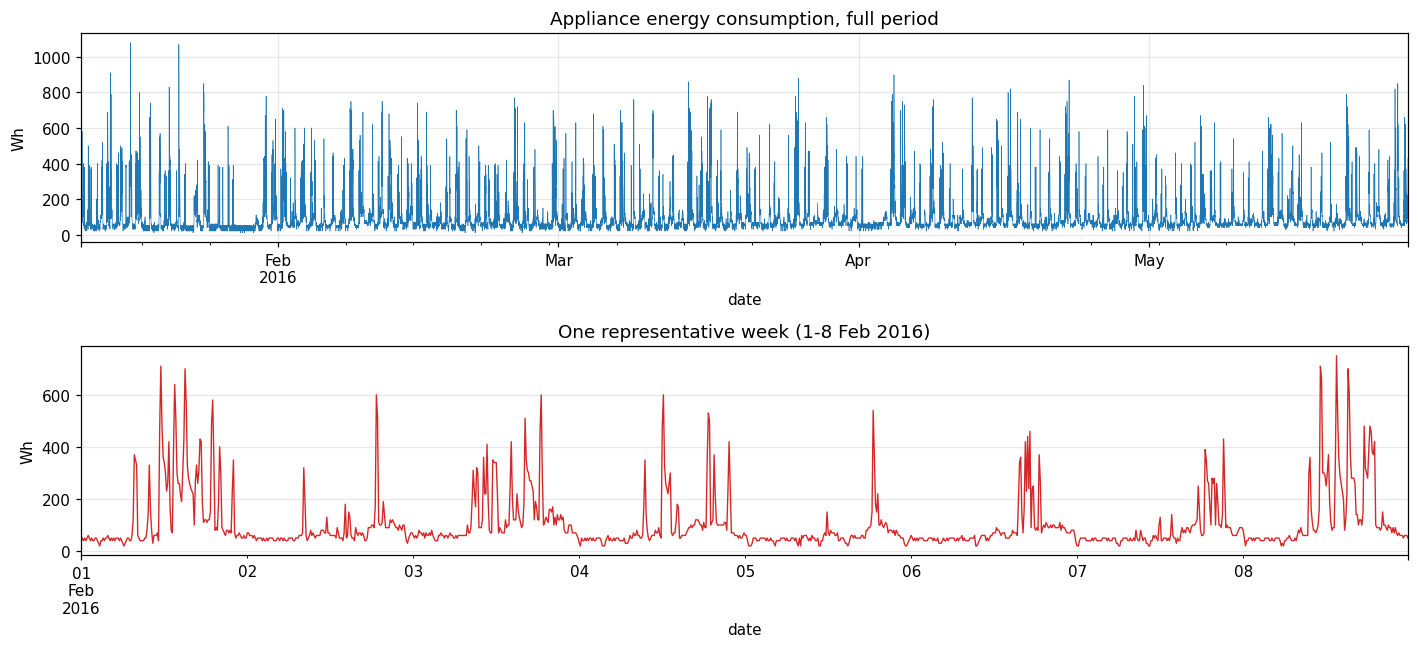

In [4]:
target = frame[config.target]

fig, ax = plt.subplots(2, 1, figsize=(13, 6))
target.plot(ax=ax[0], lw=0.4, color="tab:blue")
ax[0].set_title("Appliance energy consumption, full period")
ax[0].set_ylabel("Wh")

target.loc["2016-02-01":"2016-02-08"].plot(ax=ax[1], lw=0.9, color="tab:red")
ax[1].set_title("One representative week (1-8 Feb 2016)")
ax[1].set_ylabel("Wh")
plt.tight_layout(); plt.show()

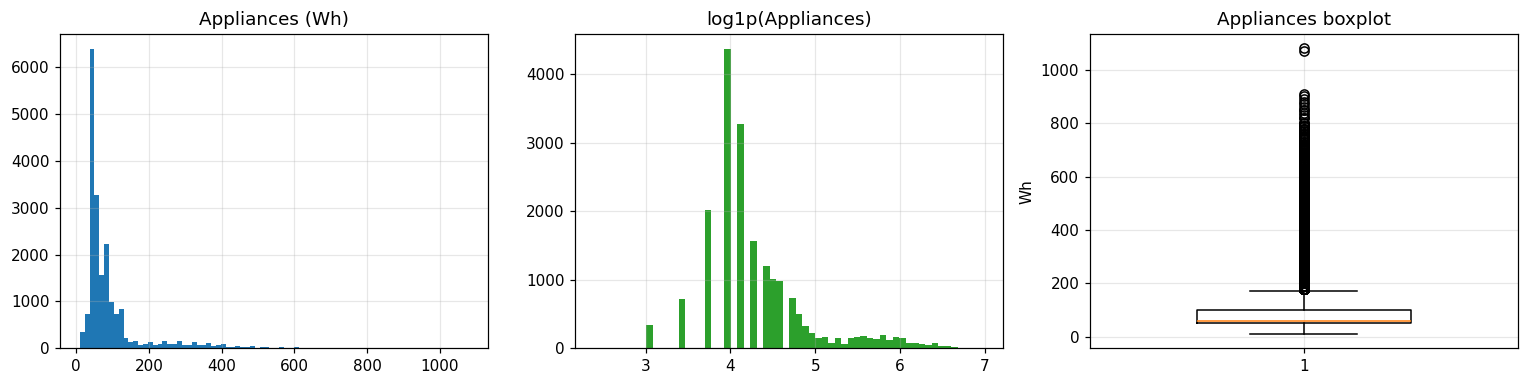

skew raw 3.39 | skew log1p 1.19 | kurtosis 13.67


In [5]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
ax[0].hist(target, bins=80, color="tab:blue")
ax[0].set_title("Appliances (Wh)")
ax[1].hist(np.log1p(target), bins=60, color="tab:green")
ax[1].set_title("log1p(Appliances)")
ax[2].boxplot(target.values, widths=0.5)
ax[2].set_title("Appliances boxplot"); ax[2].set_ylabel("Wh")
plt.tight_layout(); plt.show()

print("skew raw %.2f | skew log1p %.2f | kurtosis %.2f"
      % (target.skew(), np.log1p(target).skew(), target.kurt()))

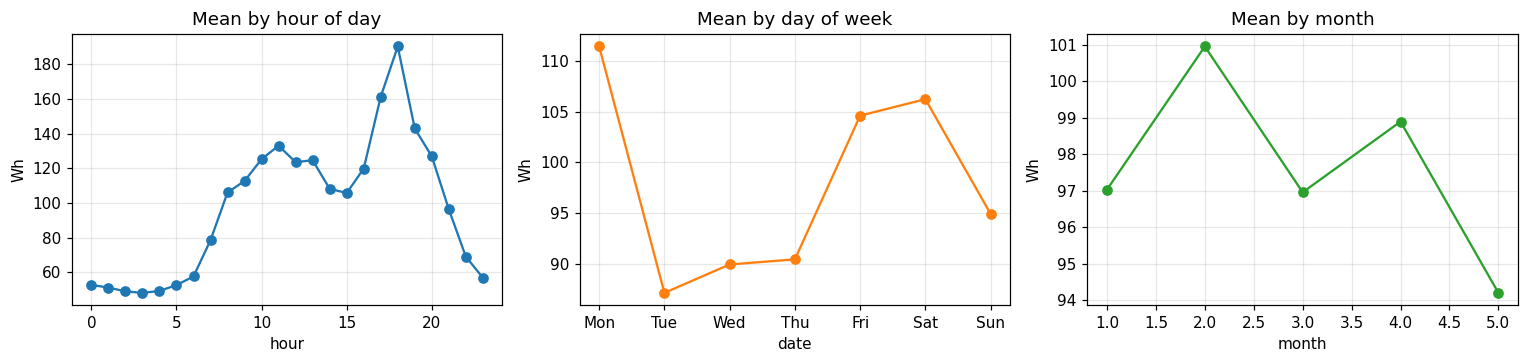

weekday     96.6
weekend    100.6


In [6]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.4))
target.groupby(target.index.hour).mean().plot(ax=ax[0], marker="o")
ax[0].set_title("Mean by hour of day"); ax[0].set_xlabel("hour"); ax[0].set_ylabel("Wh")

target.groupby(target.index.dayofweek).mean().plot(ax=ax[1], marker="o", color="tab:orange")
ax[1].set_xticks(range(7)); ax[1].set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
ax[1].set_title("Mean by day of week"); ax[1].set_ylabel("Wh")

target.groupby(target.index.month).mean().plot(ax=ax[2], marker="o", color="tab:green")
ax[2].set_title("Mean by month"); ax[2].set_xlabel("month"); ax[2].set_ylabel("Wh")
plt.tight_layout(); plt.show()

print(target.groupby(np.where(target.index.dayofweek >= 5, "weekend", "weekday"))
      .mean().round(1).to_string())

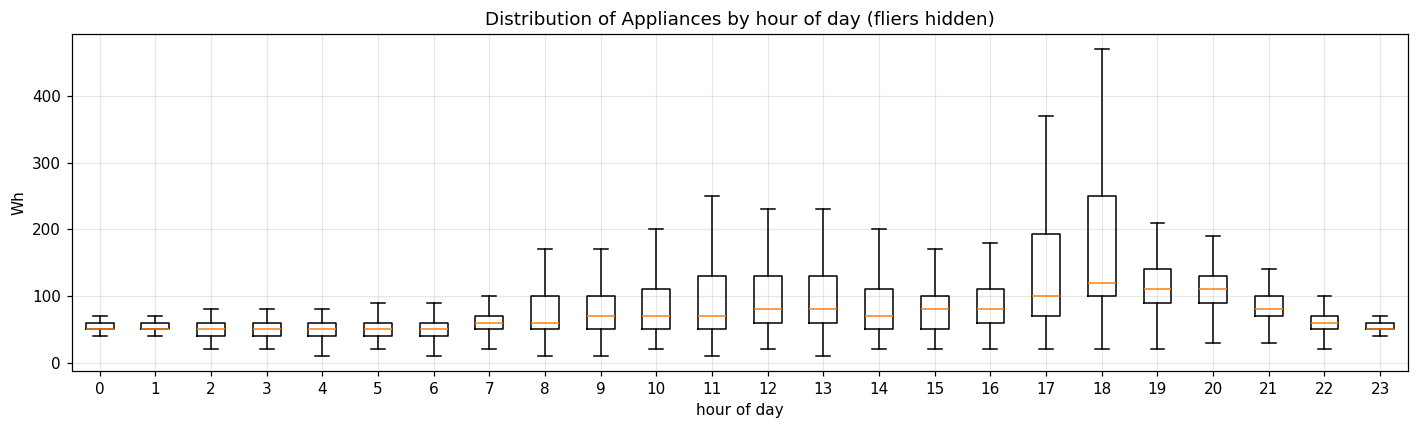

In [7]:
# Spread within each hour, not just the mean - the spikes are the interesting part.
plt.figure(figsize=(13, 4))
plt.boxplot([target[target.index.hour == h].values for h in range(24)],
            tick_labels=[str(h) for h in range(24)], showfliers=False)
plt.title("Distribution of Appliances by hour of day (fliers hidden)")
plt.xlabel("hour of day"); plt.ylabel("Wh")
plt.tight_layout(); plt.show()

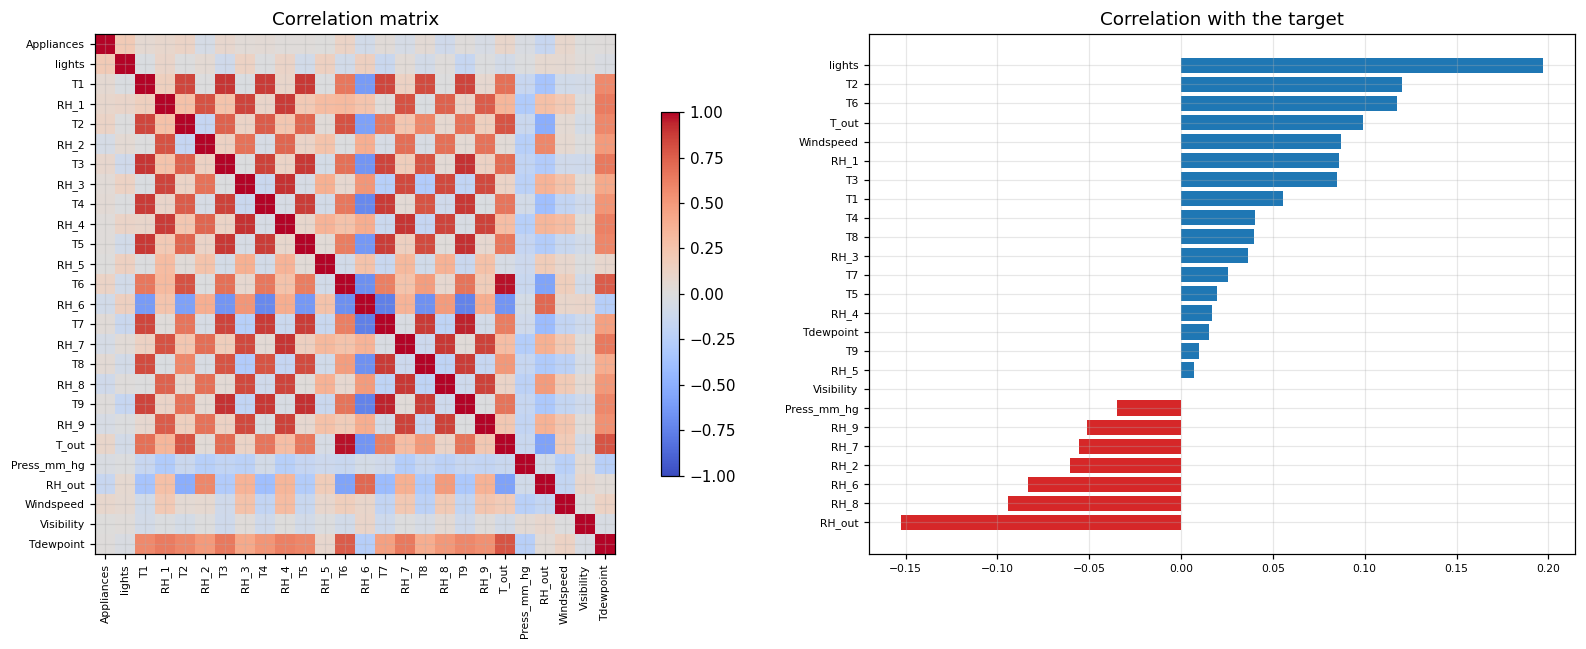

lights       0.197
RH_out       0.152
T2           0.120
T6           0.118
T_out        0.099
RH_8         0.094
Windspeed    0.087
RH_1         0.086


In [8]:
corr = frame.corr(numeric_only=True)

fig, ax = plt.subplots(1, 2, figsize=(16, 6),
                       gridspec_kw={"width_ratios": [1.3, 1]})
im = ax[0].imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
ax[0].set_xticks(range(len(corr))); ax[0].set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax[0].set_yticks(range(len(corr))); ax[0].set_yticklabels(corr.columns, fontsize=7)
ax[0].set_title("Correlation matrix"); fig.colorbar(im, ax=ax[0], shrink=0.7)

target_corr = corr[config.target].drop(config.target).sort_values()
ax[1].barh(target_corr.index, target_corr.values,
           color=["tab:red" if v < 0 else "tab:blue" for v in target_corr.values])
ax[1].set_title("Correlation with the target"); ax[1].tick_params(labelsize=7)
plt.tight_layout(); plt.show()

print(target_corr.abs().sort_values(ascending=False).head(8).round(3).to_string())

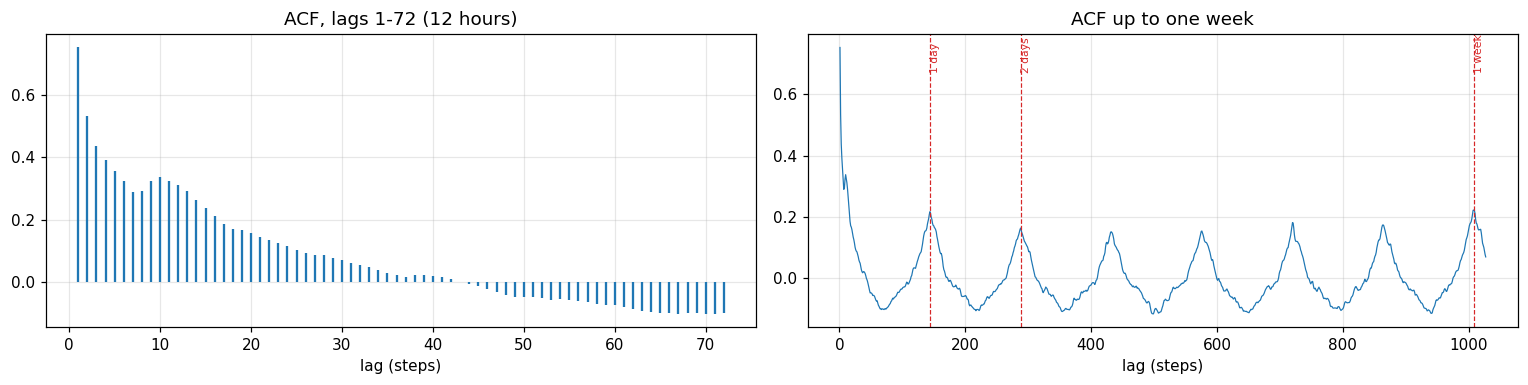

lag     1 (   10 min):  0.753
lag     2 (   20 min):  0.534
lag     3 (   30 min):  0.438
lag     6 (   60 min):  0.324
lag    12 (  120 min):  0.311
lag    18 (  180 min):  0.171
lag    36 (  360 min):  0.021
lag    72 (  720 min): -0.101
lag   144 ( 1440 min):  0.217
lag  1008 (10080 min):  0.222


In [9]:
# Autocorrelation drives the choice of lag features, so it is worth looking at properly.
steps_per_day = config.steps_per("day")
steps_per_week = config.steps_per("week")

acf_short = pd.Series({lag: target.autocorr(lag) for lag in range(1, 73)})
acf_long = pd.Series({lag: target.autocorr(lag) for lag in range(1, steps_per_week + 20)})

fig, ax = plt.subplots(1, 2, figsize=(14, 3.6))
ax[0].stem(acf_short.index, acf_short.values, markerfmt=" ", basefmt=" ")
ax[0].set_title("ACF, lags 1-72 (12 hours)"); ax[0].set_xlabel("lag (steps)")

ax[1].plot(acf_long.index, acf_long.values, lw=0.8)
for k, label in [(steps_per_day, "1 day"), (2 * steps_per_day, "2 days"), (steps_per_week, "1 week")]:
    ax[1].axvline(k, color="tab:red", ls="--", lw=0.8)
    ax[1].text(k, ax[1].get_ylim()[1] * 0.85, label, rotation=90, fontsize=7, color="tab:red")
ax[1].set_title("ACF up to one week"); ax[1].set_xlabel("lag (steps)")
plt.tight_layout(); plt.show()

for lag in [1, 2, 3, 6, 12, 18, 36, 72, steps_per_day, steps_per_week]:
    print(f"lag {lag:5d} ({lag * 10:5d} min): {target.autocorr(lag): .3f}")

### What the EDA settles

- **The target is heavily right-skewed** (skew ≈ 3.4, kurtosis ≈ 13.7; median 60 Wh against a
  maximum of 1080 Wh). A raw-scale squared-error loss would be dominated by a handful of spikes,
  so the target is modelled as `log1p(Appliances)` — which cuts the skew to about 1.2 — and
  inverted before scoring.
- **A strong daily cycle**, bottoming out around 03:00–05:00 and peaking at 17:00–18:00. Hour of
  day is the most valuable calendar feature, and it is encoded cyclically so 23:50 and 00:00 are
  adjacent rather than maximally distant.
- **A weak but real weekly effect** — weekend means sit slightly above weekday means, the opposite
  of an office building and consistent with a dwelling occupied during the day at weekends.
- **Autocorrelation ≈0.75 at one step**, decaying to ≈0.31 by two hours, with clear bumps at the
  daily (144) and weekly (1008) lags. This is the direct justification for the lag grid in
  `config.yaml`: dense short lags plus those two seasonal terms.
- **No individual exogenous sensor exceeds |r| ≈ 0.2** against the target. They are not useless,
  but this says the target's own history will dominate — and that **persistence will be a hard
  baseline to beat**, which is why it is reported first.

## 4. Missing values

Two kinds matter: explicit gaps (`NaN` cells or absent timestamps) and hidden missingness (a
frozen sensor repeating a plausible value). Both are checked in §2.

This file needs neither repaired, but the handling stays in the pipeline because it is what
guarantees the fixed spacing every lag feature assumes, and because the next batch of the same
data may not be so clean.

**Strategy where imputation would be needed:** time-weighted interpolation, capped at one hour
(`data.max_interpolation_steps: 6`). These are physical signals sampled every 10 minutes, so a
value between two neighbours is far more plausible than the series mean — and mean-filling would
flatten exactly the short-term dynamics the model exists to learn. The cap stops interpolation
from fabricating a long stretch of behaviour; anything longer stays `NaN` and its rows are dropped
when the design matrix is built.

In [10]:
# Demonstration that the handling works, on a deliberately damaged copy.
from energy_forecast.data import enforce_regular_grid

damaged = frame.drop(frame.index[500:503])          # a 30-minute dropout
repaired, inserted, interpolated = enforce_regular_grid(damaged, config)
print(f"rows removed: 3 | timestamps reinserted: {inserted} | cells interpolated: {interpolated}")
print("gap repaired cleanly:", not repaired.iloc[495:510].isna().any().any())

rows removed: 3 | timestamps reinserted: 3 | cells interpolated: 78
gap repaired cleanly: True


## 5. Outliers

Two questions hide under one heading, and they get different answers.

**Target outliers are kept.** About 11% of rows sit outside the 1.5×IQR fence, all on the high
side. They are not sensor faults — they are the evening cooking and appliance spikes the model
exists to predict. Removing them would delete the hard cases, flatter the test metrics, and punch
holes in the time grid. The skew is handled by the `log1p` transform instead, which compresses the
tail without discarding a single observation.

**Predictor outliers are capped.** Here an extreme value is more likely to be an artefact, and one
wild reading can distort a scaler that later feeds a neural network. Predictors are winsorised at
3×IQR — and critically, the fences are learned from the **training rows only**, inside
`Preprocessor.fit`, so no information about the test period leaks into preprocessing.

IQR fence: [-25, 175] Wh
beyond the fence : 2138 rows (10.83%), all above: True
|z| > 3          : 540 rows (2.74%)


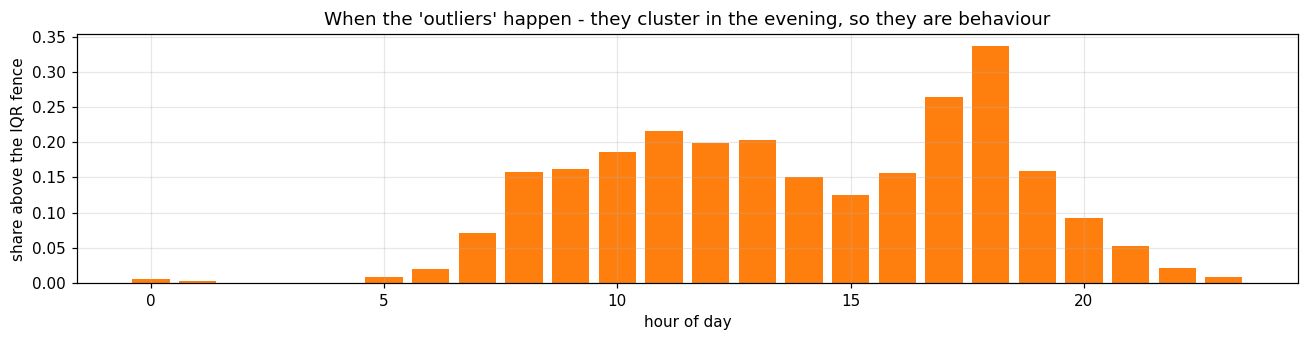

In [11]:
from energy_forecast.features import iqr_bounds

low, high = iqr_bounds(target)
beyond = (target < low) | (target > high)
z = (target - target.mean()).abs() / target.std()

print(f"IQR fence: [{low:.0f}, {high:.0f}] Wh")
print(f"beyond the fence : {int(beyond.sum())} rows ({beyond.mean():.2%}), "
      f"all above: {bool((target[beyond] > high).all())}")
print(f"|z| > 3          : {int((z > 3).sum())} rows ({(z > 3).mean():.2%})")

plt.figure(figsize=(12, 3.2))
plt.bar(range(24), (target > high).groupby(target.index.hour).mean().values, color="tab:orange")
plt.xlabel("hour of day"); plt.ylabel("share above the IQR fence")
plt.title("When the 'outliers' happen - they cluster in the evening, so they are behaviour")
plt.tight_layout(); plt.show()

## 6. Feature engineering and the leakage audit

Seven families, all built by `FeatureBuilder`:

| family | what | why |
|---|---|---|
| calendar | hour, day of week, month, weekend flag, seconds-since-midnight, sin/cos | the dominant daily cycle found in §3 |
| target lags | 1–6, 12, 18, 36, 144, 1008 | read directly off the ACF |
| rolling | mean/std/min/max over 1 h, 3 h, 6 h, 24 h | recent level *and* volatility; std separates a quiet hour from a spiky one |
| difference | 1-step, 1-hour, deviation from the 24 h mean | direction of travel, which levels alone cannot express |
| interaction | T_out×RH_out, indoor−outdoor ΔT, dew-point spread, indoor T×RH | comfort and heating drivers are products, not single variables |
| domain | Belgian public holidays, evening-peak flag | the dwelling is in Belgium; a holiday behaves like a weekend whatever its weekday |
| exogenous | all sensors, lagged | the raw channels, made serving-time-legal |

### How leakage is prevented, and proved

Leakage is the reason models that validate beautifully collapse in production, and the classic
vector is a rolling window computed without a prior shift. Three mechanisms, in increasing order
of strength:

1. **Construction** — observed series are shifted before any window is applied, so a window always
   ends strictly before the row it describes.
2. **Declaration** — every feature registers a `min_lag` and an availability class, and
   `FeatureBuilder._record` *raises* if an observed feature claims a lag below the horizon. A
   mistake fails at build time rather than silently improving the score.
3. **Proof** — `tests/test_features_leakage.py` corrupts every observation from a chosen timestamp
   onward, rebuilds the features, and asserts that no feature row at or before that timestamp
   moved. A feature that peeks into the future cannot survive this.

The audit below is the same report `make audit` prints: for every input, whether it is knowable in
advance or derived from lagged observation, and at what lag.

In [12]:
from energy_forecast.features import FeatureBuilder

builder = FeatureBuilder(config)
X_all, y_all = builder.build(frame)
audit = builder.audit()

print(f"{X_all.shape[1]} features over {len(X_all)} usable rows "
      f"({len(frame) - len(X_all)} warm-up rows dropped for the weekly lag)\n")
print(audit.groupby(["family", "availability"]).size().to_string())

observed = audit[audit.availability == "lagged_observation"]
print(f"\nminimum lag among observed features: {observed.min_lag_steps.min()} step(s) "
      f"- must be >= the horizon of {config.features['horizon']}")
audit.head(12)

77 features over 18727 usable rows (1008 warm-up rows dropped for the weekly lag)

family       availability      
calendar     known_in_advance       9
difference   lagged_observation     3
domain       known_in_advance       3
exogenous    lagged_observation    25
interaction  known_in_advance       1
             lagged_observation     7
rolling      lagged_observation    18
target_lag   lagged_observation    11

minimum lag among observed features: 1 step(s) - must be >= the horizon of 1


,family,availability,min_lag_steps,description
feature,,,,
lights_lag1,exogenous,lagged_observation,1,lights observed 1 step(s) earlier
T1_lag1,exogenous,lagged_observation,1,T1 observed 1 step(s) earlier
RH_1_lag1,exogenous,lagged_observation,1,RH_1 observed 1 step(s) earlier
T2_lag1,exogenous,lagged_observation,1,T2 observed 1 step(s) earlier
RH_2_lag1,exogenous,lagged_observation,1,RH_2 observed 1 step(s) earlier
T3_lag1,exogenous,lagged_observation,1,T3 observed 1 step(s) earlier
RH_3_lag1,exogenous,lagged_observation,1,RH_3 observed 1 step(s) earlier
T4_lag1,exogenous,lagged_observation,1,T4 observed 1 step(s) earlier
RH_4_lag1,exogenous,lagged_observation,1,RH_4 observed 1 step(s) earlier


## 7. Chronological split

A random split is invalid here. Adjacent rows correlate at ~0.75, so shuffling places a row's
immediate neighbour in the training set while the row itself sits in the test set: the model
interpolates rather than forecasts, and the metrics become meaningless.

The first 80% of the timeline trains and the last 20% tests, with no row moving. Validation is
carved off the **end** of the training block, so the ordering is always train < validation < test
in time.

,rows,start,end
split,,,
train,13482,2016-01-18 17:00:00,2016-04-21 07:50:00
validation,1499,2016-04-21 08:00:00,2016-05-01 17:40:00
test,3746,2016-05-01 17:50:00,2016-05-27 18:00:00


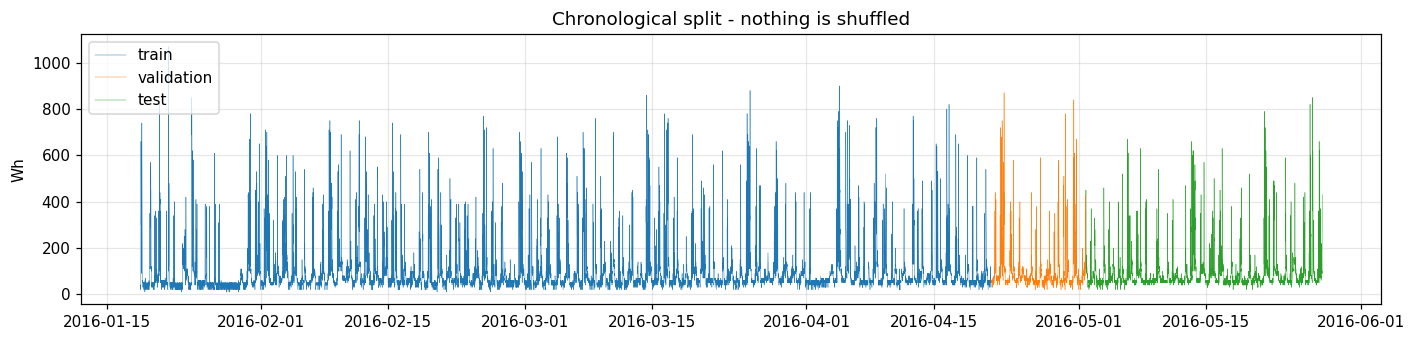

In [13]:
from energy_forecast.data import chronological_split

split = chronological_split(X_all, y_all, config)
display(split.summary)

plt.figure(figsize=(13, 3.2))
plt.plot(split.y_train.index, split.y_train, lw=0.3, label="train")
plt.plot(split.y_val.index, split.y_val, lw=0.3, label="validation")
plt.plot(split.y_test.index, split.y_test, lw=0.3, label="test")
plt.legend(loc="upper left"); plt.ylabel("Wh")
plt.title("Chronological split - nothing is shuffled")
plt.tight_layout(); plt.show()

## 8. Scaling

Scaling matters because gradient descent converges badly when inputs span orders of magnitude
(`nsm` reaches 86400 while `hour_sin` lives in [−1, 1]).

- **Predictors → `StandardScaler`.** Most engineered features are roughly bell-shaped, and
  standardisation is less sensitive to residual extremes than Min-Max, which would squash a whole
  column into a narrow band if one large value defined the range.
- **Target → `log1p`, then `StandardScaler`**, with an exact inverse so every metric is in Wh.
- **Everything is fitted on the training block only.** A scaler that has seen the test period's
  range has been told something about the future; the test suite pins this
  (`test_winsoriser_fences_come_only_from_training_rows`).

From here the notebook uses `prepare()`, which runs §2–§9 as one reproducible unit — the same
function the CLI calls.

In [14]:
artifacts = prepare(config)

print("selected features:", len(artifacts.selection.selected))
print("train matrix     :", artifacts.X_train_sel.shape)
print("test matrix      :", artifacts.X_test_sel.shape)
print("\ntrain features are centred (scaler fitted on train):",
      np.allclose(artifacts.X_train_sel.mean(axis=0), 0, atol=1e-6))
print("test features are NOT forced to zero mean, as expected:",
      not np.allclose(artifacts.X_test_sel.mean(axis=0), 0, atol=1e-2))

selected features: 30
train matrix     : (13482, 30)
test matrix      : (3746, 30)

train features are centred (scaler fitted on train): True
test features are NOT forced to zero mean, as expected: True


## 9. Feature selection

77 features, many near-duplicates — nine indoor temperature sensors in one house move together.
Handing all of them to a recurrent network multiplies parameters without adding information.

Each selector has a known blind spot: tree importance splits credit arbitrarily among correlated
columns, RFE assumes linearity, univariate correlation ignores interactions. So a feature is kept
only when at least two of the three vote for it, rather than trusting any single ranking.

30 of 77 features retained



,votes,rf_importance,selected
app_lag1,3,0.7387,True
app_dev_from_24h,2,0.0122,True
app_diff_1,2,0.0121,True
hour_cos,3,0.0089,True
app_lag2,2,0.0081,True
app_lag3,2,0.0081,True
hour_sin,3,0.0081,True
app_mean_3h,2,0.0078,True
nsm,2,0.0060,True
app_std_3h,2,0.0060,True


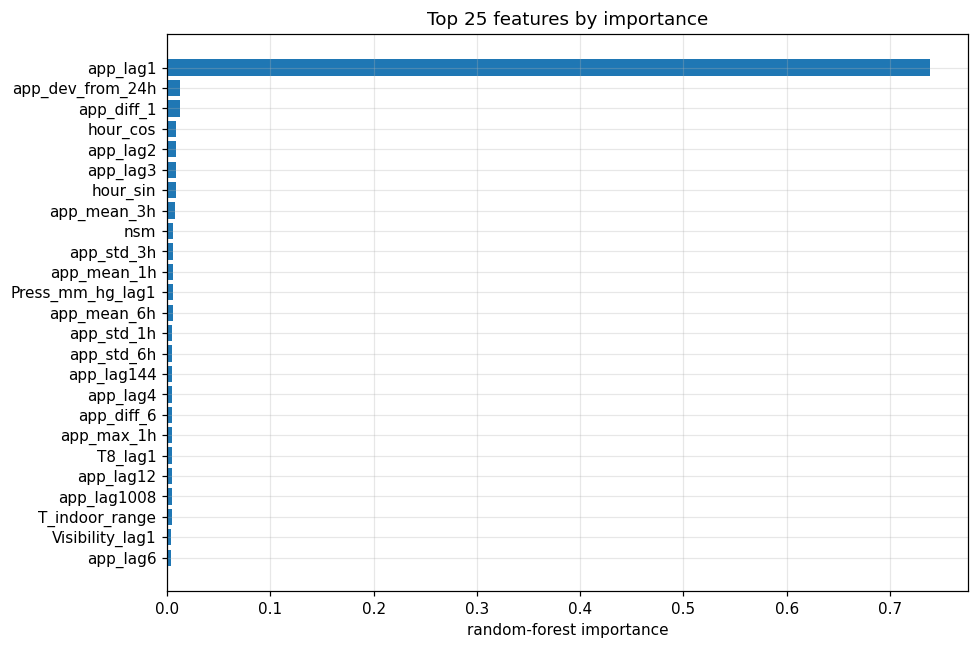

In [15]:
selection = artifacts.selection
table = selection.table

print(f"{len(selection.selected)} of {len(table)} features retained\n")
display(table.head(20).round(4))

plt.figure(figsize=(9, 6))
top = selection.importances.nlargest(25)[::-1]
plt.barh(top.index, top.values, color="tab:blue")
plt.xlabel("random-forest importance"); plt.title("Top 25 features by importance")
plt.tight_layout(); plt.show()

As the EDA predicted, the target's own recent history dominates: `app_lag1` carries most of the
importance, followed by the short rolling statistics, the 1-step difference and the time-of-day
encodings. The environmental sensors survive mainly through their aggregated and interaction
forms rather than as individual raw channels — consistent with their weak univariate correlations.

## 10. Baseline models

The point of a baseline is falsification. Three, in increasing sophistication:

- **Persistence** (`ŷ[t] = y[t−1]`) — the benchmark that actually matters at a 10-minute horizon.
  A deep model that cannot beat it has learned nothing, however good its R² looks.
- **Ridge** — a linear reference on the selected features.
- **Random forest** — a non-linear reference with no sequence structure.

In [16]:
artifacts = run_baseline_stage(artifacts)
artifacts.comparison.round(3)

,mae,rmse,mape,r2,n
model,,,,,
Ridge,24.716,60.358,21.029,0.522,3746
Persistence,25.678,64.654,21.665,0.451,3746
RandomForest,26.742,59.680,23.008,0.532,3746


## 11. Deep learning models

Three architectures, each testing a different hypothesis:

- **LSTM** — gated recurrence holds the daily level while still reacting to a sudden spike.
- **GRU** — one fewer gate, ~25% fewer parameters. With ~13k training windows the cheaper model
  may generalise better; worth measuring rather than assuming.
- **CNN-LSTM** — a causal 1-D convolution compresses local shape (the 10–30 minute ramp) before
  the LSTM handles the longer dependency.

Choices and their reasons: `tanh` recurrent activation (the Keras default, and the only setting
that uses the fused cuDNN kernel — ReLU inside a recurrent loop tends to explode); a `relu` dense
head with a **linear output** (predictions live in standardised log space and must be free to go
negative); **Adam** (adaptive per-parameter rates cope with mixed feature scales — RMSprop is in
the tuning search space rather than ruled out by assertion); **MSE** loss, which is what RMSE
reports on; and dropout plus early stopping as the regularisers.

Windows are 36 steps (6 hours): long enough to cover the evening ramp-up and the range where
autocorrelation is still non-trivial, short enough to keep training cheap.

**This stage needs TensorFlow** (`pip install -e ".[deep]"`). Everything above runs without it.

In [17]:
artifacts = run_deep_stage(artifacts, verbose=0)
artifacts.comparison.round(3)

,mae,rmse,mape,r2,n
model,,,,,
Ridge,24.716,60.358,21.029,0.522,3746
Persistence,25.678,64.654,21.665,0.451,3746
RandomForest,26.742,59.680,23.008,0.532,3746
gru,29.540,69.853,23.984,0.359,3746
lstm,29.726,71.349,23.338,0.332,3746
cnn_lstm,33.497,83.090,24.605,0.094,3746


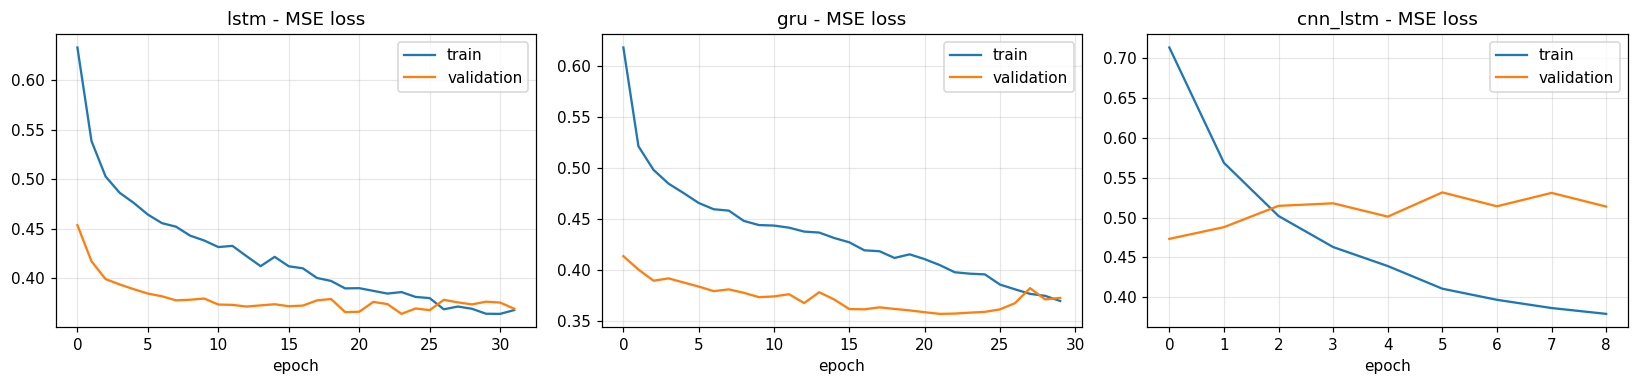

In [18]:
fig = ev.plot_training_history(artifacts.histories)
plt.show()

The loss curves are the first place to look for overfitting: a validation curve turning upward
while training keeps falling means the dropout rate or the model size needs adjusting. Early
stopping uses `restore_best_weights=True`, so the weights kept are from the best validation epoch
rather than the last — without that flag, early stopping merely stops late.

## 12. Evaluation and residual analysis

All metrics on the held-out final 20%, in Wh:

- **MAE** — average absolute error, robust to the spikes. The headline number.
- **RMSE** — quadratic penalty, so it reflects how badly the evening peaks are missed. RMSE much
  larger than MAE is expected here given the skew.
- **MAPE** — relative error, inflated by the many low-consumption night rows where a 20 Wh miss is
  a large percentage. Reported, not optimised.
- **R²** — variance explained.

Note that once the deep stage runs, the baselines are re-scored on the windowed test rows, so
every model in the table is judged on an identical set of timestamps.

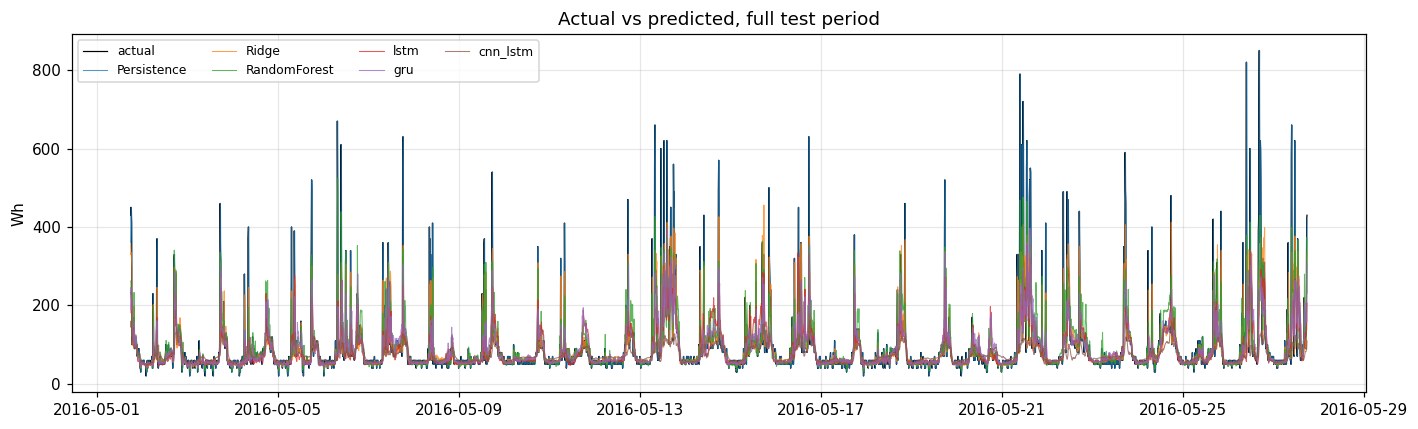

In [19]:
actual = artifacts.test_actual
index = artifacts.sequences.test_index

fig = ev.plot_actual_vs_predicted(index, actual, artifacts.predictions,
                                  "Actual vs predicted, full test period")
plt.show()

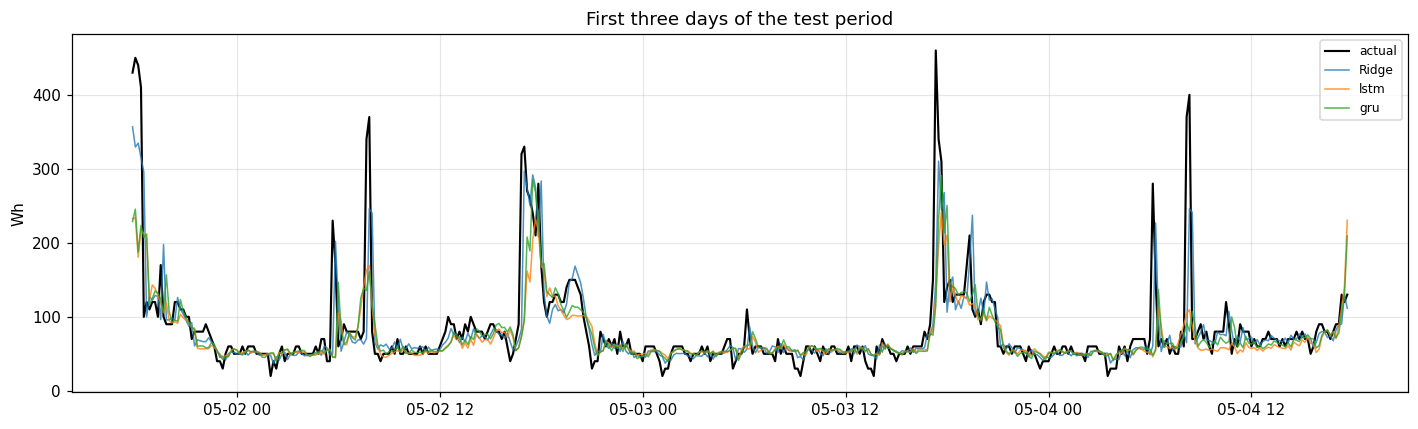

In [20]:
# Three days, where per-spike behaviour is actually visible.
best = artifacts.comparison.index[0]
zoom = slice(0, 3 * config.steps_per("day"))

plt.figure(figsize=(13, 4))
plt.plot(index[zoom], actual[zoom], lw=1.4, color="black", label="actual")
for name in [best] + [m for m in ("lstm", "gru") if m in artifacts.predictions and m != best]:
    plt.plot(index[zoom], artifacts.predictions[name][-len(actual):][zoom], lw=1.0,
             alpha=0.8, label=name)
plt.ylabel("Wh"); plt.title("First three days of the test period")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

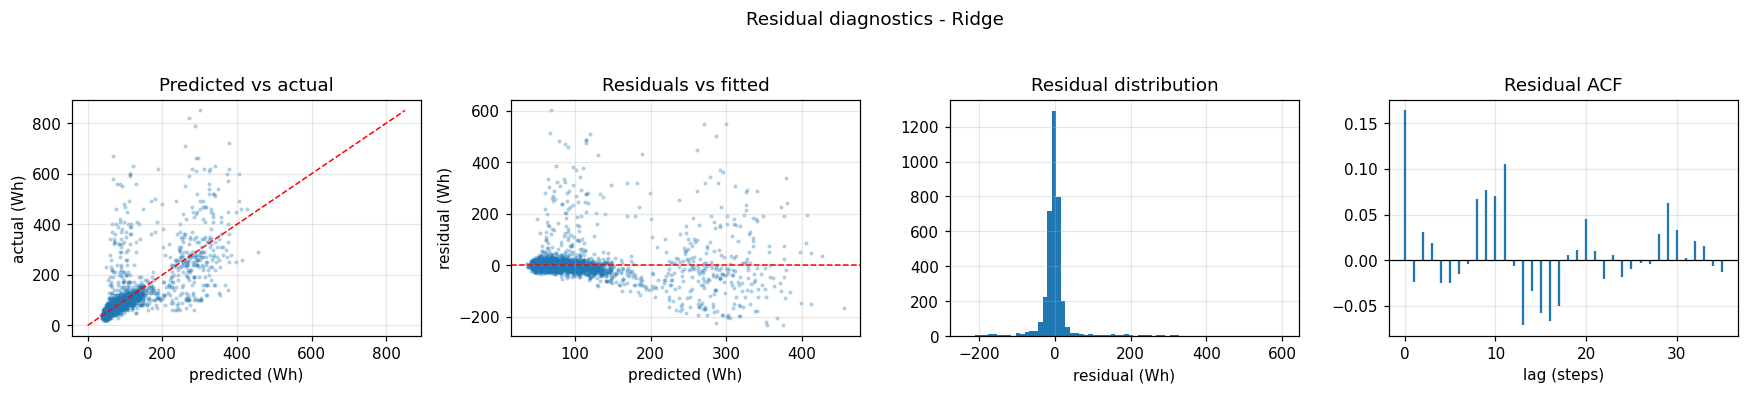

residual mean 4.03 Wh | std 60.22 Wh | skew 3.83

         mean_abs_error  rows
<50                9.44  1048
50-100            11.37  1728
100-200           32.55   684
200-400           88.56   199
>400             266.20    87


In [21]:
fig = ev.plot_residual_diagnostics(actual, artifacts.predictions[best][-len(actual):], best)
plt.show()

residual = actual - artifacts.predictions[best][-len(actual):]
print("residual mean %.2f Wh | std %.2f Wh | skew %.2f"
      % (residual.mean(), residual.std(), pd.Series(residual).skew()))
print()
print(error_by_level(actual, artifacts.predictions[best][-len(actual):]).to_string())

Read the residual panel left to right: whether the model tracks the level; whether error grows
with the prediction (heteroscedasticity is expected — the spikes are the hard part); whether the
error distribution is biased or heavy-tailed; and — the strictest test — whether autocorrelation
remains in the residuals. Leftover residual autocorrelation would mean predictable structure the
features have not captured, and would be the first thing to attack with more lags or a longer
lookback.

The error-by-level table makes the practical limitation explicit: error on quiet low-consumption
periods is small, while the large errors sit almost entirely in the high-consumption spikes.

## 13. Optimisation

Three levers on the best recurrent architecture:

1. **Random search** over units, dropout, learning rate, batch size and optimiser. Random beats an
   exhaustive grid at this budget — with a handful of fits it covers each dimension far better
   than a coarse grid, and a full grid over five hyper-parameters is unaffordable for a recurrent
   model.
2. **Dropout rates** are in the search space, so the effect shows up in the trial table rather
   than being asserted.
3. **Early stopping** on validation loss plus `ReduceLROnPlateau`.

Selection happens on the **validation** block; the test block is scored once, afterwards.

In [22]:
artifacts = run_tuning_stage(artifacts, verbose=0)

from energy_forecast.training import trials_table

trials_table(artifacts.trials).round(4)

,units,dropout,learning_rate,batch_size,optimizer,val_mae_wh,val_loss,epochs
0,64,0.3,0.0030,128,rmsprop,33.7589,0.3609,40
1,64,0.2,0.0030,64,adam,33.7782,0.3744,20
2,32,0.3,0.0010,64,adam,34.0713,0.3740,40
3,64,0.1,0.0003,64,rmsprop,34.1480,0.3768,27
4,64,0.2,0.0003,128,rmsprop,34.3464,0.3749,40
5,96,0.2,0.0003,128,adam,34.3892,0.3700,40
6,32,0.3,0.0030,32,rmsprop,34.7121,0.3908,40
7,96,0.1,0.0030,32,adam,34.8050,0.3865,13


In [23]:
# Before and after tuning, on the test set.
tuned = [m for m in artifacts.comparison.index if m.endswith("_tuned")]
if tuned:
    base = tuned[0].replace("_tuned", "")
    cols = ["mae", "rmse", "mape", "r2"]
    delta = pd.DataFrame({
        "before": artifacts.comparison.loc[base, cols].astype(float),
        "after": artifacts.comparison.loc[tuned[0], cols].astype(float),
    })
    delta["change"] = delta["after"] - delta["before"]
    delta["change_%"] = delta["change"] / delta["before"].abs() * 100
    display(delta.round(3))

,before,after,change,change_%
mae,29.540,28.575,-0.965,-3.266
rmse,69.853,70.080,0.227,0.326
mape,23.984,22.766,-1.217,-5.076
r2,0.359,0.355,-0.004,-1.163


## 14. Results

The table and the summary below are generated from the objects in memory, so they always describe
the run that just executed. The same numbers are written to `reports/metrics.json` by
`make train`, in machine-readable form — which is what a scheduled retrain would compare against
the model currently deployed.

,mae,rmse,mape,r2,n
model,,,,,
Ridge,24.716,60.358,21.029,0.522,3746
Persistence,25.678,64.654,21.665,0.451,3746
RandomForest,26.742,59.680,23.008,0.532,3746
gru_tuned,28.575,70.080,22.766,0.355,3746
gru,29.540,69.853,23.984,0.359,3746
lstm,29.726,71.349,23.338,0.332,3746
cnn_lstm,33.497,83.090,24.605,0.094,3746


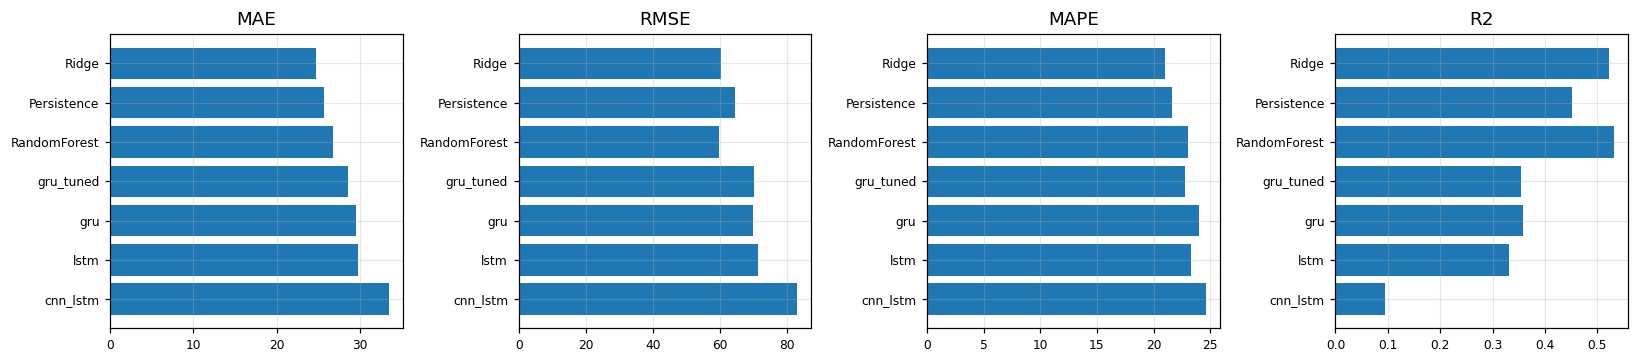

Best model on the test set: Ridge
  MAE  24.72 Wh
  RMSE 60.36 Wh
  MAPE 21.03 %
  R2   0.522
Against persistence: +3.7% MAE (25.68 -> 24.72 Wh)
Test mean consumption: 94.4 Wh


In [24]:
final = artifacts.comparison.round(3)
display(final)

fig = ev.plot_metric_comparison(final)
plt.show()

print(ev.summarise(artifacts.metrics, actual))

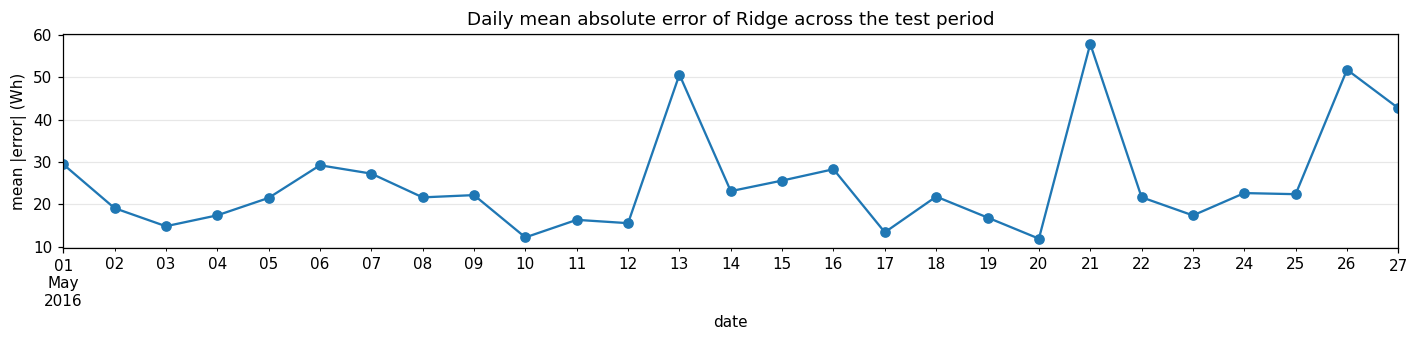

In [25]:
# Does accuracy hold up across the whole test month, or decay?
errors = pd.Series(np.abs(actual - artifacts.predictions[final.index[0]][-len(actual):]),
                   index=index)
plt.figure(figsize=(13, 3.2))
errors.resample("1D").mean().plot(marker="o")
plt.ylabel("mean |error| (Wh)")
plt.title(f"Daily mean absolute error of {final.index[0]} across the test period")
plt.tight_layout(); plt.show()

## 15. Challenges

**Leakage is easy to introduce and invisible once introduced.** An early version computed
`rolling(6).mean()` directly on the target, which includes the current value; validation error
collapsed to something implausible. The fix was structural rather than a one-line patch: shift
before every window, lag the exogenous sensors, declare a `min_lag` per feature, and add a test
that corrupts the future and asserts the past does not move. That test is now the most valuable
thing in the repository.

**Beating persistence is genuinely hard at this horizon.** With lag-1 autocorrelation of 0.75,
"the value is what it was ten minutes ago" is already strong. Almost all the achievable gain has
to come from the spike periods — exactly where the residual analysis shows the error concentrates.
The flip side is that an implausibly large win over persistence is a leakage alarm, which is why
it is pinned as a test rather than celebrated.

**The target is spiky, not smooth.** Squared-error training on the raw scale chases the spikes and
degrades everywhere else; the `log1p` transform is what made the recurrent models train stably.

**Warm-up cost of long lags.** The weekly lag discards the first seven days (1008 rows of 19,735)
— a real trade-off for capturing the weekly ACF bump, not a free feature.

**Structuring for reuse costs upfront time.** A single notebook would have reached a first number
sooner. The package pays that back the first time a feature has to change: the change happens in
one function, and the test suite says immediately whether it broke the leakage guarantee.

## 16. Conclusion and future work

The pipeline is: enforce a regular time grid → keep the target's real spikes but tame the skew
with `log1p`, winsorising only the predictors → engineer calendar, lag, rolling, difference,
interaction and holiday features under mechanically-enforced leakage rules → select by agreement
across three methods → train persistence, Ridge and random-forest baselines against LSTM, GRU and
CNN-LSTM → tune the best recurrent architecture by random search on validation only.

What holds regardless of the exact run: the target's own recent history dominates every other
input; time of day is the strongest exogenous signal; individual temperature and humidity sensors
contribute little alone and matter mainly through aggregates and interactions; and error is
concentrated in the high-consumption evening spikes rather than spread across the day. §14 has the
numbers for this run.

Worth doing next, roughly in order of value:

- **Longer horizons.** Ten minutes ahead is the easiest case. Re-running at 1 h and 6 h — a
  one-line config change, since `horizon` is a parameter — would show how fast the edge over
  persistence decays and would be far more useful operationally.
- **Walk-forward validation** across several consecutive folds instead of one held-out block, to
  turn a single estimate into a distribution.
- **Quantile loss.** Since error concentrates in the peaks, a prediction interval (pinball loss at
  0.1/0.5/0.9) would be more informative than a point forecast.
- **Attention or temporal-fusion architectures**, which handle long-range dependence better than a
  fixed 6-hour window and expose which past steps drove a prediction.
- **Occupancy proxies.** `lights` is a crude occupancy signal; a joint estimate across sensors
  would likely help most precisely where the model is weakest.
- **Operational hardening**: a model registry, drift monitoring against the saved
  `DataQualityReport`, and a scheduled retrain gated on `reports/metrics.json`.

## 17. References

1. Candanedo, L. M., Feldheim, V., Deramaix, D. (2017). *Data driven prediction models of energy
   use of appliances in a low-energy house.* Energy and Buildings, 140, 81–97.
2. UCI Machine Learning Repository — Appliances Energy Prediction Data Set.
3. Chollet, F. *Deep Learning with Python*, 2nd ed., Manning, 2021.
4. Hyndman, R. J., Athanasopoulos, G. *Forecasting: Principles and Practice*, 3rd ed.
5. TensorFlow, *Time series forecasting* tutorial.
6. Kedro and Cookiecutter Data Science — project-structure conventions this repository follows.